# Incarcarea dataset-ului

In [2]:
import os
import pandas as pd
import numpy as np

def load_smd_data(data_path):
    """
    Loads the Server Machine Dataset (SMD) from the extracted archive.
    Assumes the standard SMD directory structure:
    - train/
    - test/
    - test_label/
    """
    train_path = os.path.join(data_path, 'train')
    test_path = os.path.join(data_path, 'test')
    label_path = os.path.join(data_path, 'test_label')
    
    # We will collect all machines' data into lists of DataFrames
    train_dfs = []
    test_dfs = []
    label_dfs = []
    
    # SMD files are typically named machine-1-1.txt, machine-1-2.txt, etc.
    if not os.path.exists(train_path):
        raise FileNotFoundError(f"Could not find train folder at {train_path}")
        
    machine_files = sorted([f for f in os.listdir(train_path) if f.endswith('.txt')])
    
    print(f"Found {len(machine_files)} machine files. Loading into memory...")
    
    for file_name in machine_files:
        # 1. Load Training Data
        # SMD txt files are comma-separated with 38 columns and no header
        train_file = os.path.join(train_path, file_name)
        df_train = pd.read_csv(train_file, header=None)
        train_dfs.append(df_train)
        
        # 2. Load Testing Data
        test_file = os.path.join(test_path, file_name)
        df_test = pd.read_csv(test_file, header=None)
        test_dfs.append(df_test)
        
        # 3. Load Testing Labels
        label_file = os.path.join(label_path, file_name)
        df_label = pd.read_csv(label_file, header=None)
        label_dfs.append(df_label)

    # Concatenate all machines into unified DataFrames
    full_train_df = pd.concat(train_dfs, ignore_index=True)
    full_test_df = pd.concat(test_dfs, ignore_index=True)
    full_label_df = pd.concat(label_dfs, ignore_index=True)
    
    print(f"Total Raw Training Shape: {full_train_df.shape}")
    print(f"Total Raw Testing Shape: {full_test_df.shape}")
    
    return full_train_df, full_test_df, full_label_df

# ==========================================
# Execution & Splits
# ==========================================

# Replace with the actual path to your extracted SMD folder
smd_folder_path = './ServerMachineDataset' 

try:
    full_train_df, test_df, test_labels_df = load_smd_data(smd_folder_path)

    # Create the Validation Set from the Train Set
    # We hold out the last 20% of the training data chronologically
    val_split_index = int(len(full_train_df) * 0.8)

    train_df = full_train_df.iloc[:val_split_index].copy()
    val_df = full_train_df.iloc[val_split_index:].copy()

    print(f"--- Final Data Splits ---")
    print(f"Train DataFrame:      {train_df.shape}")
    print(f"Validation DataFrame: {val_df.shape}")
    print(f"Test DataFrame:       {test_df.shape}")
    print(f"Test Labels Array:    {test_labels_df.shape}")

except Exception as e:
    print(f"Error loading data: {e}")

Found 28 machine files. Loading into memory...
Total Raw Training Shape: (708405, 38)
Total Raw Testing Shape: (708420, 38)
--- Final Data Splits ---
Train DataFrame:      (566724, 38)
Validation DataFrame: (141681, 38)
Test DataFrame:       (708420, 38)
Test Labels Array:    (708420, 1)


# Definirirea Anomaly Attention si Forward

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class AnomalyAttention(nn.Module):
    def __init__(self, d_model=512, h=8, window_size=100):
        super(AnomalyAttention, self).__init__()
        self.d_model = d_model
        self.h = h
        self.d_k = d_model // h
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_sigma = nn.Linear(d_model, h) # Learnable scale for Gaussian kernel
        
        self.out_proj = nn.Linear(d_model, d_model)
        
        # Pre-compute relative distance matrix D
        idx = torch.arange(window_size, dtype=torch.float32)
        # D[i, j] = |i - j|^2
        self.register_buffer('D', (idx.unsqueeze(1) - idx.unsqueeze(0)) ** 2)

    def forward(self, x):
        B, N, C = x.size() # Batch, Window_size, d_model
        
        # 1. Linear projections and split for multi-head
        Q = self.W_q(x).view(B, N, self.h, self.d_k).transpose(1, 2) # [B, h, N, d_k]
        K = self.W_k(x).view(B, N, self.h, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(B, N, self.h, self.d_k).transpose(1, 2)
        
        # Learnable scale for prior-association
        sigma = self.W_sigma(x) # [B, N, h]
        sigma = F.softplus(sigma) + 1e-5 # Ensure strictly positive
        sigma = sigma.transpose(1, 2).unsqueeze(-1) # [B, h, N, 1]
        
        # 2. Prior-Association (Gaussian Kernel)
        # P_m = (1 / sqrt(2*pi*sigma)) * exp(-D / 2*sigma^2)
        D_expanded = self.D.unsqueeze(0).unsqueeze(0) # [1, 1, N, N]
        prior_assoc = (1.0 / (math.sqrt(2 * math.pi) * sigma)) * torch.exp(-D_expanded / (2 * sigma ** 2))
        prior_assoc = prior_assoc / (prior_assoc.sum(dim=-1, keepdim=True) + 1e-8) # Rescale
        
        # 3. Series-Association (Standard Self-Attention)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        series_assoc = F.softmax(scores, dim=-1)
        
        # 4. Reconstruction
        Z = torch.matmul(series_assoc, V) # [B, h, N, d_k]
        Z = Z.transpose(1, 2).contiguous().view(B, N, self.d_model)
        
        out = self.out_proj(Z)
        
        return out, prior_assoc, series_assoc

# Compunerea Association Discrepancy
Conform formulei din articol 

In [4]:
import torch
import torch.nn.functional as F

def compute_association_discrepancy(prior_list, series_list):
    """
    Calculates the multi-layer Symmetrized KL Divergence (Association Discrepancy).
    
    Args:
        prior_list: List of Length L (layers). Each item is a prior-association 
                    tensor of shape [Batch, Heads, N, N].
        series_list: List of Length L (layers). Each item is a series-association 
                     tensor of shape [Batch, Heads, N, N].
        
    Returns:
        ass_dis: Tensor of shape [Batch, N] containing the point-wise discrepancy.
    """
    # 1. Stack the lists into tensors of shape: [Batch, Layers, Heads, N, N]
    P_all = torch.stack(prior_list, dim=1)
    S_all = torch.stack(series_list, dim=1)
    
    # 2. Average the distributions across the attention heads (dim=2) 
    # Resulting shape: [Batch, Layers, N, N]
    P_mean = P_all.mean(dim=2)
    S_mean = S_all.mean(dim=2)
    
    # Add a small epsilon to prevent log(0) issues
    epsilon = 1e-8
    P_mean = P_mean + epsilon
    S_mean = S_mean + epsilon
    
    # Normalize again to ensure they remain valid probability distributions after adding epsilon
    P_mean = P_mean / P_mean.sum(dim=-1, keepdim=True)
    S_mean = S_mean / S_mean.sum(dim=-1, keepdim=True)
    
    # 3. Compute Symmetrized KL Divergence across the sequence dimension (dim=-1) 
    # In PyTorch: F.kl_div(input, target) computes KL(target || input)
    # Therefore, we pass the log of the "input" distribution.
    
    # KL(P || S)
    kl_P_S = F.kl_div(S_mean.log(), P_mean, reduction='none').sum(dim=-1) # Shape: [Batch, Layers, N]
    
    # KL(S || P)
    kl_S_P = F.kl_div(P_mean.log(), S_mean, reduction='none').sum(dim=-1) # Shape: [Batch, Layers, N]
    
    # Combine for the symmetrized metric
    sym_kl = kl_P_S + kl_S_P 
    
    # 4. Average the discrepancy across all layers (dim=1) 
    # Resulting shape: [Batch, N]
    ass_dis = sym_kl.mean(dim=1)
    
    return ass_dis

In [5]:
import torch.nn as nn

class EncoderLayer(nn.Module):
    # Added window_size to the constructor
    def __init__(self, d_model=512, h=8, d_ff=2048, dropout=0.1, window_size=100):
        super(EncoderLayer, self).__init__()
        
        # Pass window_size down to the attention block
        self.attention = AnomalyAttention(d_model=d_model, h=h, window_size=window_size)
        
        # Standard Feed-Forward network
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )
        
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # 1. Anomaly Attention with residual connection
        attn_out, prior, series = self.attention(x)
        x = x + self.dropout(attn_out)
        x = self.norm1(x)
        
        # 2. Feed-Forward with residual connection
        ffn_out = self.ffn(x)
        x = x + self.dropout(ffn_out)
        x = self.norm2(x)
        
        return x, prior, series

class AnomalyTransformer(nn.Module):
    # Added window_size (and d_ff, dropout for completeness) to the constructor
    def __init__(self, c_in=38, d_model=512, L=3, h=8, d_ff=2048, dropout=0.1, window_size=100):
        super(AnomalyTransformer, self).__init__()
        
        # Initial projection from raw features (38 for SMD) to hidden state (512)
        self.embedding = nn.Linear(c_in, d_model) 
        
        # Stack L layers and pass all required parameters down
        self.layers = nn.ModuleList([
            EncoderLayer(d_model=d_model, h=h, d_ff=d_ff, dropout=dropout, window_size=window_size) 
            for _ in range(L)
        ])
        
        # Final projection back to raw feature space for reconstruction
        self.projection = nn.Linear(d_model, c_in)

    def forward(self, x):
        prior_list = []
        series_list = []
        
        # Embed input
        x = self.embedding(x)
        
        # Pass through each layer and collect associations
        for layer in self.layers:
            x, prior, series = layer(x)
            prior_list.append(prior)
            series_list.append(series)
            
        # Reconstruct the original series
        reconstruction = self.projection(x)
        
        return reconstruction, prior_list, series_list

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

class SMDDataset(Dataset):
    def __init__(self, data_array, window_size=100, is_train=True, scaler=None):
        """
        Args:
            data_array: A numpy array or pandas DataFrame of shape [Sequence_Length, 38].
            window_size: Fixed at 100 per the paper.
            is_train: Boolean to determine if we fit the scaler or just transform.
            scaler: A pre-fitted sklearn scaler (required if is_train=False).
        """
        raw_data = np.array(data_array, dtype=np.float32)
        
        # 1. Normalize the Data
        if is_train:
            self.scaler = StandardScaler()
            self.data = self.scaler.fit_transform(raw_data)
        else:
            if scaler is None:
                raise ValueError("A fitted scaler must be provided for validation/test sets.")
            self.scaler = scaler
            self.data = self.scaler.transform(raw_data)
            
        self.window_size = window_size
        
        # 2. Create non-overlapping windows
        # Calculate how many full windows we can extract
        self.num_windows = len(self.data) // self.window_size
        
        # Truncate the tail end of the data that doesn't fit into a perfect window of 100
        self.data = self.data[:self.num_windows * self.window_size]
        
        # Reshape directly into [num_windows, window_size, 38]
        self.windows = self.data.reshape(self.num_windows, self.window_size, -1)

    def __len__(self):
        return self.num_windows

    def __getitem__(self, idx):
        return torch.tensor(self.windows[idx])

In [7]:
from torch.utils.data import DataLoader

print("Initializing Datasets and scaling data (this might take a few seconds)...")

# 1. Initialize Datasets
# We use the DataFrames you created in your first cell
train_dataset = SMDDataset(train_df, window_size=100, is_train=True)

# Pass the train dataset's scaler to the validation and test sets to prevent data leakage
val_dataset = SMDDataset(val_df, window_size=100, is_train=False, scaler=train_dataset.scaler)
test_dataset = SMDDataset(test_df, window_size=100, is_train=False, scaler=train_dataset.scaler)

# 2. Initialize DataLoaders
# The paper specifies a batch size of 32
batch_size = 32

print("Creating DataLoaders...")
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Initializing Datasets and scaling data (this might take a few seconds)...
Creating DataLoaders...
Train batches: 178 | Val batches: 45 | Test batches: 222


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

# --- Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

# Initialize Model (from Step 2)
model = AnomalyTransformer(c_in=38, d_model=512, L=3, h=8, window_size=100).to(device)

# Hyperparameters (from the paper's SMD configuration)
epochs = 10
lambda_weight = 3.0
optimizer = Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

# --- Training Loop ---
for epoch in range(epochs):
    model.train()
    epoch_loss_min = 0.0
    epoch_loss_max = 0.0
    
    for batch_idx, batch_x in enumerate(train_loader):
        batch_x = batch_x.to(device)
        
        # Zero gradients for the whole model
        optimizer.zero_grad()
        
        # Forward pass
        reconstruction, prior_list, series_list = model(batch_x)
        
        # Calculate base reconstruction loss
        rec_loss = criterion(reconstruction, batch_x)
        
        # ==========================================
        # 1. Minimize Phase
        # ==========================================
        # Detach series_list so gradients only flow through the prior (Gaussian)
        series_detached = [s.detach() for s in series_list]
        ass_dis_min = compute_association_discrepancy(prior_list, series_detached)
        
        # Loss: Minimize Reconstruction + Minimize Discrepancy
        loss_min = rec_loss + (lambda_weight * ass_dis_min.mean())
        
        # Backpropagate but retain the graph for the second phase
        loss_min.backward(retain_graph=True)
        epoch_loss_min += loss_min.item()
        
        # ==========================================
        # 2. Maximize Phase
        # ==========================================
        # Detach prior_list so gradients only flow through the series (Self-Attention)
        prior_detached = [p.detach() for p in prior_list]
        ass_dis_max = compute_association_discrepancy(prior_detached, series_list)
        
        # Loss: Minimize Reconstruction - Maximize Discrepancy
        loss_max = rec_loss - (lambda_weight * ass_dis_max.mean())
        
        loss_max.backward()
        epoch_loss_max += loss_max.item()
        
        # Update weights for both phases simultaneously
        optimizer.step()
        
    print(f"Epoch [{epoch+1}/{epochs}] | Min Phase Loss: {epoch_loss_min/len(train_loader):.4f} | Max Phase Loss: {epoch_loss_max/len(train_loader):.4f}")

# ==========================================
# Salvarea Checkpoint-ului
# ==========================================
# Alegem un nume sugestiv pentru fisier (ex: pentru SMD)
checkpoint_path = 'anomaly_transformer_smd.pth'

# Salvam dictionarul cu ponderile invatate
torch.save(model.state_dict(), checkpoint_path)

print(f"Antrenare finalizată! Modelul a fost salvat cu succes în: {checkpoint_path}")

print("Training Complete!")

Training on: cpu
Epoch [1/10] | Min Phase Loss: 54.2412 | Max Phase Loss: -53.3772
Epoch [2/10] | Min Phase Loss: 61.7971 | Max Phase Loss: -61.1238
Epoch [3/10] | Min Phase Loss: 63.7232 | Max Phase Loss: -63.0989
Epoch [4/10] | Min Phase Loss: 62.3917 | Max Phase Loss: -61.8011
Epoch [5/10] | Min Phase Loss: 60.8597 | Max Phase Loss: -60.3044
Epoch [6/10] | Min Phase Loss: 59.9416 | Max Phase Loss: -59.4079
Epoch [7/10] | Min Phase Loss: 59.2853 | Max Phase Loss: -58.7829
Epoch [8/10] | Min Phase Loss: 58.8503 | Max Phase Loss: -58.3654
Epoch [9/10] | Min Phase Loss: 58.5346 | Max Phase Loss: -58.0619
Epoch [10/10] | Min Phase Loss: 58.2599 | Max Phase Loss: -57.7995
Antrenare finalizată! Modelul a fost salvat cu succes în: anomaly_transformer_smd.pth
Training Complete!


# Incarcarea Modelului pentru Testare

In [9]:
import torch

print("Inițializăm arhitectura modelului...")

model_test = AnomalyTransformer(c_in=38, d_model=512, L=3, h=8, window_size=100).to(device)

checkpoint_path = 'anomaly_transformer_smd.pth'
model_test.load_state_dict(torch.load(checkpoint_path, map_location=device))

model_test.eval()

print("Modelul a fost încărcat cu succes și este gata pentru inferență!")


Inițializăm arhitectura modelului...
Modelul a fost încărcat cu succes și este gata pentru inferență!


In [8]:
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

def get_anomaly_scores(model, dataloader, device):
    """
    Passes data through the model and calculates the Anomaly Score 
    for every single time point in the dataset.
    """
    model.eval()
    all_scores = []
    
    with torch.no_grad():
        for batch_x in dataloader:
            batch_x = batch_x.to(device)
            
            # Forward pass
            reconstruction, prior_list, series_list = model(batch_x)
            
            # 1. Calculate Association Discrepancy
            ass_dis = compute_association_discrepancy(prior_list, series_list) # [Batch, Window_Size]
            
            # 2. Calculate Reconstruction Error (MSE per point across features)
            # batch_x and reconstruction are [Batch, Window_Size, Features]
            rec_error = torch.mean((batch_x - reconstruction) ** 2, dim=-1) # [Batch, Window_Size]
            
            # 3. Final Anomaly Score Calculation
            # Softmax is applied across the window dimension (dim=1)
            score = F.softmax(-ass_dis, dim=1) * rec_error
            
            # Flatten to a 1D array and store
            all_scores.append(score.cpu().numpy().flatten())
            
    return np.concatenate(all_scores)

In [9]:
def apply_point_adjust(predictions, labels):
    """
    If any point in a true continuous anomaly segment is predicted as an anomaly,
    the entire segment is counted as correctly predicted.
    """
    adjusted_preds = predictions.copy()
    in_anomaly_segment = False
    start_idx = 0
    
    # 1. Find all continuous anomaly segments in the ground truth
    segments = []
    for i in range(len(labels)):
        if labels[i] == 1 and not in_anomaly_segment:
            start_idx = i
            in_anomaly_segment = True
        elif labels[i] == 0 and in_anomaly_segment:
            segments.append((start_idx, i))
            in_anomaly_segment = False
            
    if in_anomaly_segment:
        segments.append((start_idx, len(labels)))
        
    # 2. Adjust predictions based on the segments
    for (start, end) in segments:
        # If the model caught at least one point in this segment
        if np.sum(adjusted_preds[start:end]) > 0:
            adjusted_preds[start:end] = 1 # Mark the whole segment as caught
            
    return adjusted_preds

In [10]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# --- 1. Extract Scores ---
print("Calculating Validation Scores...")
val_scores = get_anomaly_scores(model, val_loader, device)

print("Calculating Test Scores...")
test_scores = get_anomaly_scores(model, test_loader, device)

# --- 2. Determine Threshold (delta) ---
# The paper uses the top r=0.5% of the validation dataset for SMD
r_ratio = 0.005 
threshold = np.percentile(val_scores, 100 * (1 - r_ratio))
print(f"Calculated Threshold (top 0.5% of Val): {threshold:.6f}")

# --- 3. Binarize Predictions ---
raw_test_preds = (test_scores >= threshold).astype(int)

# --- 4. Prepare Ground Truth Labels ---
# Convert the pandas DataFrame of labels into a flat 1D numpy array
raw_labels = test_labels_df.values.flatten()

# Truncate the labels to perfectly match the length of our predictions.
# This accounts for any leftover data points dropped by the sliding window.
test_labels_array = raw_labels[:len(raw_test_preds)]

# --- 5. Point-Adjust & Evaluate ---
print("Applying Point-Adjust Strategy...")
adjusted_preds = apply_point_adjust(raw_test_preds, test_labels_array)

precision, recall, f1, _ = precision_recall_fscore_support(
    test_labels_array, 
    adjusted_preds, 
    average='binary'
)

print("\n--- Final SMD Replication Metrics ---")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall:    {recall * 100:.2f}%")
print(f"F1-Score:  {f1 * 100:.2f}%")

Calculating Validation Scores...
Calculating Test Scores...
Calculated Threshold (top 0.5% of Val): 0.083292
Applying Point-Adjust Strategy...

--- Final SMD Replication Metrics ---
Precision: 93.29%
Recall:    80.34%
F1-Score:  86.33%


Matplotlib is building the font cache; this may take a moment.


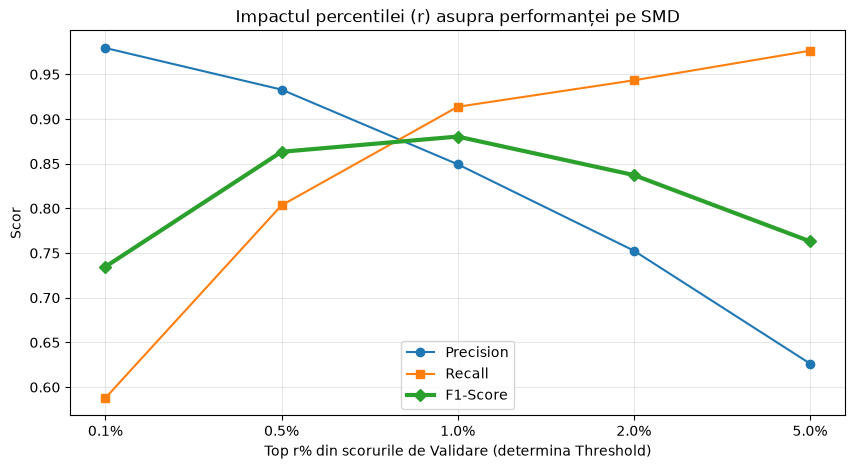

In [12]:
import matplotlib.pyplot as plt

def analyze_threshold_impact(val_scores, test_scores, labels_array):
    r_values = [0.001, 0.005, 0.01, 0.02, 0.05] # de la 0.1% la 5%
    results = []

    for r in r_values:
        thresh = np.percentile(val_scores, 100 * (1 - r))
        preds = (test_scores >= thresh).astype(int)
        adj_preds = apply_point_adjust(preds, labels_array)
        
        p, r_sc, f1, _ = precision_recall_fscore_support(labels_array, adj_preds, average='binary')
        results.append((r, p, r_sc, f1))

    # Plotting
    r_labels = [f"{v*100}%" for v in r_values]
    plt.figure(figsize=(10, 5))
    plt.plot(r_labels, [res[1] for res in results], marker='o', label='Precision')
    plt.plot(r_labels, [res[2] for res in results], marker='s', label='Recall')
    plt.plot(r_labels, [res[3] for res in results], marker='D', label='F1-Score', linewidth=3)
    plt.title("Impactul percentilei (r) asupra performanței pe SMD")
    plt.xlabel("Top r% din scorurile de Validare (determina Threshold)")
    plt.ylabel("Scor")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return results

# Rulează analiza
tuning_results = analyze_threshold_impact(val_scores, test_scores, test_labels_array)

Începem evaluarea hiperparametrului Lambda...
\n--- Antrenare cu lambda_weight = 0.1 ---
Lambda: 0.1 -> F1-Score: 0.8523
\n--- Antrenare cu lambda_weight = 1.0 ---
Lambda: 1.0 -> F1-Score: 0.8677
\n--- Antrenare cu lambda_weight = 3.0 ---
Lambda: 3.0 -> F1-Score: 0.8790
\n--- Antrenare cu lambda_weight = 5.0 ---
Lambda: 5.0 -> F1-Score: 0.8661


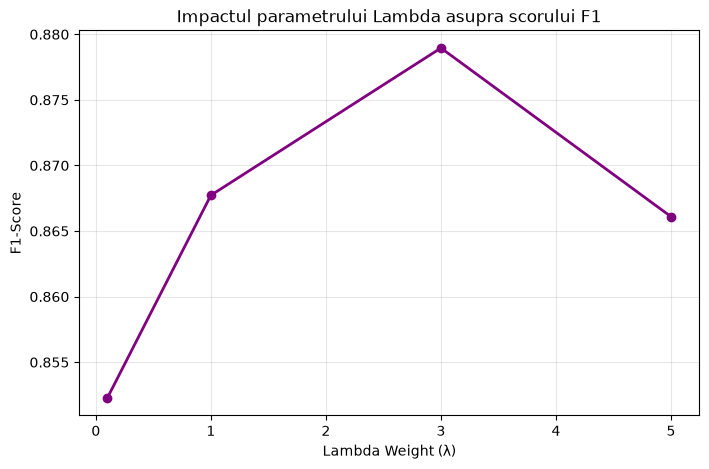

In [17]:
def analyze_lambda_impact(train_loader, val_loader, test_loader, test_labels_array, device):
    lambda_values = [0.1, 1.0, 3.0, 5.0]
    f1_scores = []
    
    print("Începem evaluarea hiperparametrului Lambda...")
    
    for l_weight in lambda_values:
        print(f"\\n--- Antrenare cu lambda_weight = {l_weight} ---")
        # Inițializăm un model nou pentru fiecare test
        temp_model = AnomalyTransformer(c_in=38, d_model=512, L=3, h=8, window_size=100).to(device)
        optimizer = torch.optim.Adam(temp_model.parameters(), lr=1e-4)
        criterion = torch.nn.MSELoss()
        
        # Antrenăm rapid (ex. doar 3 epoci pentru experiment)
        temp_model.train()
        for epoch in range(3): 
            for batch_x in train_loader:
                batch_x = batch_x.to(device)
                optimizer.zero_grad()
                reconstruction, prior_list, series_list = temp_model(batch_x)
                rec_loss = criterion(reconstruction, batch_x)
                
                # Faza Minim
                series_detached = [s.detach() for s in series_list]
                ass_dis_min = compute_association_discrepancy(prior_list, series_detached)
                loss_min = rec_loss + (l_weight * ass_dis_min.mean())
                loss_min.backward(retain_graph=True)
                
                # Faza Maxim
                prior_detached = [p.detach() for p in prior_list]
                ass_dis_max = compute_association_discrepancy(prior_detached, series_list)
                loss_max = rec_loss - (l_weight * ass_dis_max.mean())
                loss_max.backward()
                optimizer.step()
                
        # Evaluare
        val_scores = get_anomaly_scores(temp_model, val_loader, device)
        test_scores = get_anomaly_scores(temp_model, test_loader, device)
        
        threshold = np.percentile(val_scores, 100 * (1 - 0.005))
        raw_test_preds = (test_scores >= threshold).astype(int)
        adjusted_preds = apply_point_adjust(raw_test_preds, test_labels_array)
        
        _, _, f1, _ = precision_recall_fscore_support(test_labels_array, adjusted_preds, average='binary')
        f1_scores.append(f1)
        print(f"Lambda: {l_weight} -> F1-Score: {f1:.4f}")

    # Vizualizare
    plt.figure(figsize=(8, 5))
    plt.plot(lambda_values, f1_scores, marker='o', color='purple', linewidth=2)
    plt.title("Impactul parametrului Lambda asupra scorului F1")
    plt.xlabel("Lambda Weight (λ)")
    plt.ylabel("F1-Score")
    plt.grid(True, alpha=0.3)
    plt.show()

# Rulează analiza (durează câteva minute)
analyze_lambda_impact(train_loader, val_loader, test_loader, test_labels_array, device)

In [15]:
def deep_dive_failure_case(idx, test_scores, test_dataset, model, device):
    """
    Extrage scorul local de Discrepanță pentru o fereastră specifică
    care conține eroarea, explicând de ce scorul a fost generat astfel.
    """
    window_idx = idx // 100
    point_idx = idx % 100
    
    # Extragem fereastra cu problema
    window_tensor = test_dataset[window_idx].unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        reconstruction, prior_list, series_list = model(window_tensor)
        ass_dis = compute_association_discrepancy(prior_list, series_list)
        rec_error = torch.mean((window_tensor - reconstruction) ** 2, dim=-1)
        
    ass_dis_np = ass_dis.cpu().numpy().flatten()
    rec_error_np = rec_error.cpu().numpy().flatten()
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    
    # Plot 1: Eroarea de reconstrucție în fereastră
    axes[0].plot(rec_error_np, color='teal')
    axes[0].axvline(x=point_idx, color='red', linestyle='--', label='Punctul Erorii')
    axes[0].set_title(f"Eroare de Reconstrucție (Fereastra {window_idx})")
    axes[0].legend()
    
    # Plot 2: Discrepanța de Asociere (KL Divergence)
    axes[1].plot(ass_dis_np, color='darkorange')
    axes[1].axvline(x=point_idx, color='red', linestyle='--', label='Punctul Erorii')
    axes[1].set_title(f"Discrepanța de Asociere (Focusul Modelului)")
    axes[1].legend()
    
    plt.show()

# Exemplu de utilizare (Apelează după ce rulezi visualize_failures și obții un index FP/FN):
# fp_idx = 12050 # (Înlocuiește cu indexul generat din funcția ta anterioară)
# deep_dive_failure_case(fp_idx, test_scores, test_dataset, model, device)

Număr total de False Positives (Alarme false): 1701
Număr total de False Negatives (Anomalii ratate): 5789

=== Vizualizare Generală a Eșecurilor ===


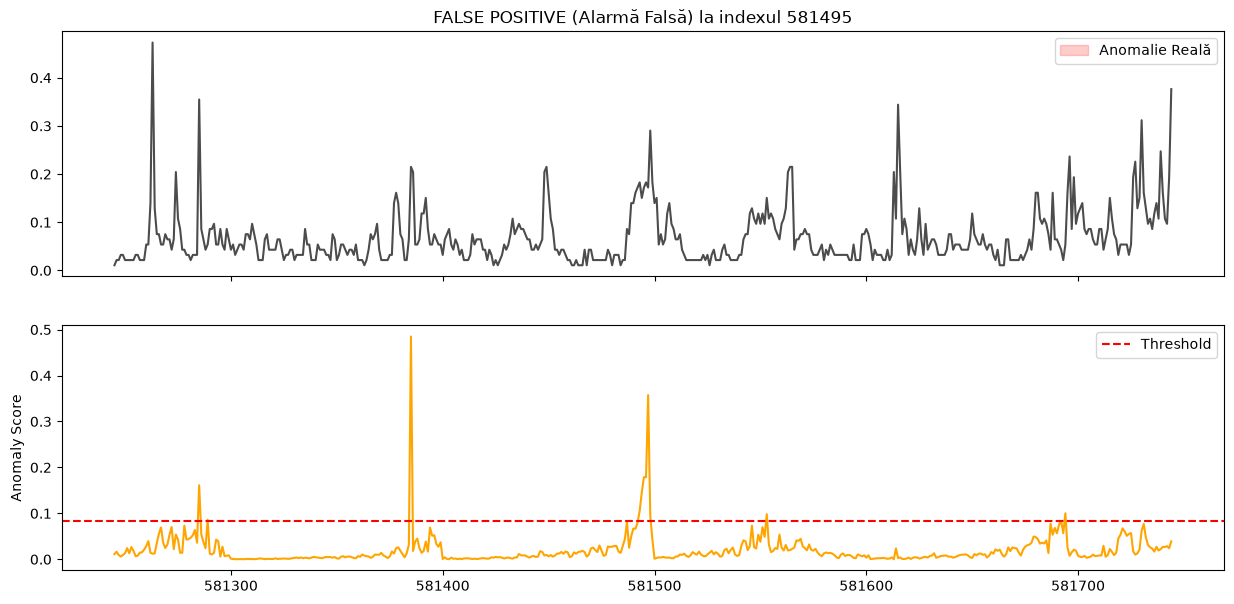

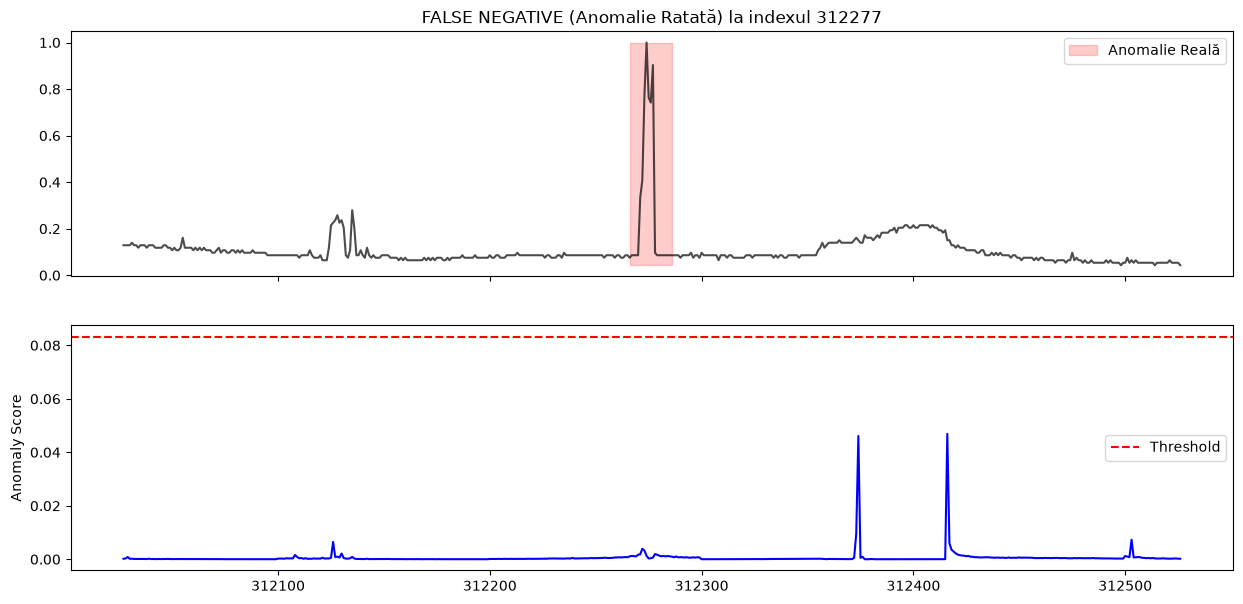


=== Investigare Mecanism intern pentru False Positive (Index: 581495) ===
Așteptăm să vedem o Discrepanță mare de Asociere (KL Divergence) pe un semnal care aparent este normal.


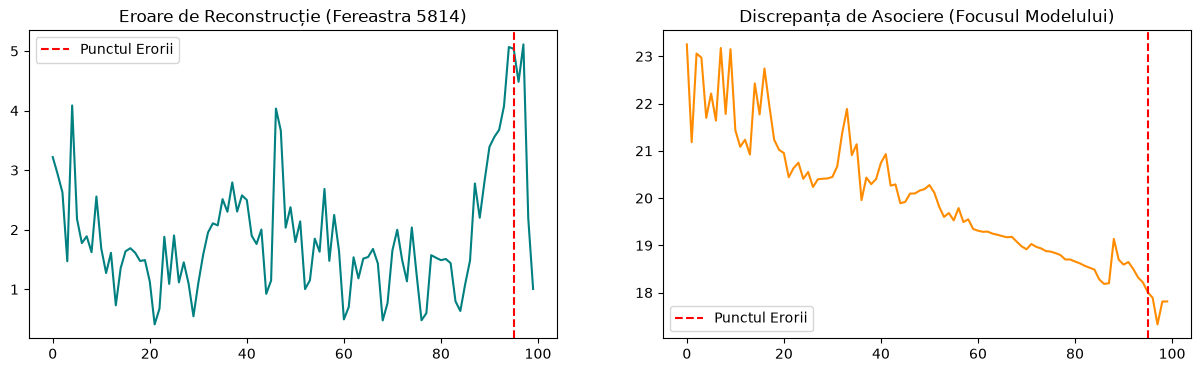


=== Investigare Mecanism intern pentru False Negative (Index: 312277) ===
Așteptăm să vedem o Discrepanță mică (Prior-ul și Series-ul s-au aliniat incorect) deși există o anomalie.


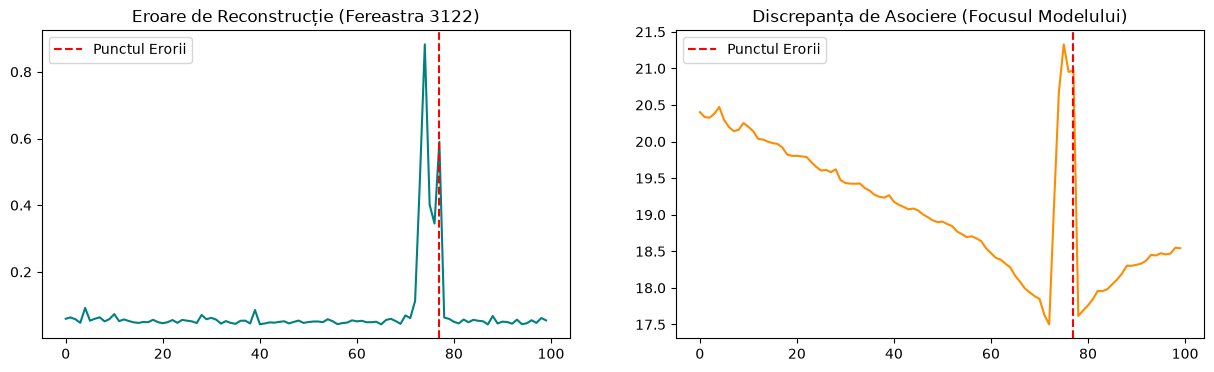

In [16]:
import numpy as np

# 1. Extragem indicii pentru FP și FN
labels = test_labels_array.flatten()
preds = adjusted_preds.flatten()

fp_indices = np.where((labels == 0) & (preds == 1))[0]
fn_indices = np.where((labels == 1) & (preds == 0))[0]

print(f"Număr total de False Positives (Alarme false): {len(fp_indices)}")
print(f"Număr total de False Negatives (Anomalii ratate): {len(fn_indices)}")

# 2. Apelăm funcția generală de vizualizare (dacă vrei să vezi contextul semnalului)
print("\n=== Vizualizare Generală a Eșecurilor ===")
raw_test_np = test_df.values[:len(test_scores)]
visualize_failures(test_scores, adjusted_preds, test_labels_array, raw_test_np, threshold)

# 3. Facem Deep-Dive pe un caz de False Positive
if len(fp_indices) > 0:
    # Luăm un index de pe la mijlocul listei de erori pentru a evita marginile
    fp_idx = fp_indices[len(fp_indices) // 2]
    print(f"\n=== Investigare Mecanism intern pentru False Positive (Index: {fp_idx}) ===")
    print("Așteptăm să vedem o Discrepanță mare de Asociere (KL Divergence) pe un semnal care aparent este normal.")
    deep_dive_failure_case(fp_idx, test_scores, test_dataset, model, device)
else:
    print("\nNu există False Positives în predicții!")

# 4. Facem Deep-Dive pe un caz de False Negative
if len(fn_indices) > 0:
    # Luăm un index de pe la mijlocul listei de erori
    fn_idx = fn_indices[len(fn_indices) // 2]
    print(f"\n=== Investigare Mecanism intern pentru False Negative (Index: {fn_idx}) ===")
    print("Așteptăm să vedem o Discrepanță mică (Prior-ul și Series-ul s-au aliniat incorect) deși există o anomalie.")
    deep_dive_failure_case(fn_idx, test_scores, test_dataset, model, device)
else:
    print("\nNu există False Negatives în predicții!")